# 04 — Commercial Real Estate Model

Trains **two RandomForest models** on Belgian commercial Immoweb data:
- `commercial_sale_model.pkl`  — predicts sale price (€)
- `commercial_rent_model.pkl`  — predicts monthly rent (€/month)

**Prerequisites:**
1. Run `python data/scrape_commercial.py` → `data/commercial_raw.json`
2. Ensure `data/statbel_features.csv` exists (run `python data/fetch_statbel.py` if not)

**Outputs (saved to `immo_api/models/`):**
- `commercial_sale_model.pkl`
- `commercial_rent_model.pkl`
- `commercial_sale_metadata.json`
- `commercial_rent_metadata.json`

In [1]:
import json, math, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

RAW_PATH     = Path('../data/commercial_raw.json')
STATBEL_PATH = Path('../data/statbel_features.csv')
MODEL_DIR    = Path('../immo_api/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Raw data file exists: {RAW_PATH.exists()}')
print(f'Statbel file exists:  {STATBEL_PATH.exists()}')

Raw data file exists: True
Statbel file exists:  True


## 1. Load raw data

In [2]:
with open(RAW_PATH, encoding='utf-8') as f:
    records = json.load(f)

df = pd.DataFrame(records)
print(f'Loaded {len(df):,} records')
print(f'Columns: {df.columns.tolist()}')
print(f'\nTransaction split:')
print(df['TypeOfTransaction'].value_counts())
print(f'\nSubtype split:')
print(df['SubtypeOfProperty'].value_counts())

Loaded 1,648 records
Columns: ['PropertyId', 'Url', 'SubtypeOfProperty', 'TypeOfTransaction', 'Price', 'TotalSurface', 'PostalCode', 'Locality', 'Latitude', 'Longitude', 'Region', 'StateOfBuilding', 'ConstructionYear', 'FloorCount', 'FloorNumber', 'HasLift', 'HasParking', 'ParkingCount', 'HeatingType', 'PEB']

Transaction split:
TypeOfTransaction
for_sale    1219
for_rent     429
Name: count, dtype: int64

Subtype split:
SubtypeOfProperty
BUSINESS                         436
COMMERCIAL_PREMISES              344
OFFICES                          192
WAREHOUSE                        138
HOUSE                            136
MIXED_USE_BUILDING_COMMERCIAL     98
INDUSTRIAL_PREMISES               84
APARTMENT                         50
HOTEL_RESTAURANT_CAFE             50
OFFICE_BLOCK                      36
MIXED_USE_BUILDING_OFFICES        23
VILLA                             14
BUILDING                          10
EXCEPTIONAL_PROPERTY               5
GROUND_FLOOR                       5
MI

## 2. Clean & filter

In [3]:
before = len(df)

# Drop records without price or surface
df = df.dropna(subset=['Price', 'TotalSurface'])
df['Price']        = pd.to_numeric(df['Price'],        errors='coerce')
df['TotalSurface'] = pd.to_numeric(df['TotalSurface'], errors='coerce')
df = df.dropna(subset=['Price', 'TotalSurface'])

# ── Filter: keep only true commercial subtypes ────────────────────────────────
# Immoweb "commercial" search also returns residential investment properties
# (HOUSE, APARTMENT, VILLA, etc.) — these must be removed before training.
COMMERCIAL_SUBTYPES = {
    'BUSINESS', 'COMMERCIAL_PREMISES', 'MIXED_USE_BUILDING_COMMERCIAL',
    'HOTEL_RESTAURANT_CAFE', 'OFFICE_BLOCK', 'OFFICES', 'MIXED_USE_BUILDING_OFFICES',
    'WAREHOUSE', 'INDUSTRIAL_PREMISES', 'MIXED_USE_BUILDING_INDUSTRIES',
    'MIXED_USE_BUILDING', 'GROUND_FLOOR',
}
df = df[df['SubtypeOfProperty'].str.upper().isin(COMMERCIAL_SUBTYPES)]
print(f'After commercial subtype filter: {len(df):,} records')

# Price filters (sale vs rent treated separately)
sale_mask = df['TypeOfTransaction'] == 'for_sale'
rent_mask = df['TypeOfTransaction'] == 'for_rent'

df = df[
    (sale_mask & df['Price'].between(50_000, 50_000_000)) |
    (rent_mask & df['Price'].between(200, 100_000))
]

# Surface filter
df = df[df['TotalSurface'].between(10, 50_000)]

print(f'After all filters: {len(df):,} records (removed {before - len(df):,} total)')
print(f'  For sale:  {(df["TypeOfTransaction"] == "for_sale").sum():,}')
print(f'  For rent:  {(df["TypeOfTransaction"] == "for_rent").sum():,}')
print(f'\nSubtype breakdown:')
print(df['SubtypeOfProperty'].value_counts().to_string())

After commercial subtype filter: 1,413 records
After all filters: 1,406 records (removed 242 total)
  For sale:  1,084
  For rent:  322

Subtype breakdown:
SubtypeOfProperty
BUSINESS                         434
COMMERCIAL_PREMISES              342
OFFICES                          191
WAREHOUSE                        137
MIXED_USE_BUILDING_COMMERCIAL     97
INDUSTRIAL_PREMISES               84
HOTEL_RESTAURANT_CAFE             50
OFFICE_BLOCK                      36
MIXED_USE_BUILDING_OFFICES        23
GROUND_FLOOR                       5
MIXED_USE_BUILDING_INDUSTRIES      4
MIXED_USE_BUILDING                 3


## 3. PostalCode & coordinates

In [4]:
df['PostalCode'] = pd.to_numeric(df['PostalCode'], errors='coerce').fillna(1000).astype(int)
df['Latitude']   = pd.to_numeric(df['Latitude'],   errors='coerce')
df['Longitude']  = pd.to_numeric(df['Longitude'],  errors='coerce')

# Postal-code centroid fallback for records without GPS
postal_geo = (
    df.dropna(subset=['Latitude', 'Longitude'])
      .groupby('PostalCode')
      .agg(lat_med=('Latitude', 'median'), lon_med=('Longitude', 'median'))
      .reset_index()
)
miss = df['Latitude'].isna()
df_miss = df[miss].merge(postal_geo, on='PostalCode', how='left')
df.loc[miss, 'Latitude']  = df_miss['lat_med'].values
df.loc[miss, 'Longitude'] = df_miss['lon_med'].values

# Belgian centroid as last fallback
df['Latitude']  = df['Latitude'].fillna(50.5)
df['Longitude'] = df['Longitude'].fillna(4.5)

print(f'Missing coords after fallback: {df["Latitude"].isna().sum()}')

Missing coords after fallback: 0


## 4. Categorical encoding

In [5]:
# Commercial type → ordinal
COMMERCIAL_TYPE_MAP = {
    'COMMERCIAL': 0, 'RETAIL': 0, 'SHOP': 0,
    'OFFICE': 1, 'OFFICES': 1,
    'WAREHOUSE': 2, 'STORAGE': 2,
    'INDUSTRIAL': 3, 'INDUSTRY': 3,
    'HORECA': 4, 'RESTAURANT': 4, 'HOTEL': 4,
}
df['CommercialType_Num'] = (
    df['SubtypeOfProperty'].str.upper()
      .map(COMMERCIAL_TYPE_MAP)
      .fillna(0)  # unknown → treat as commercial/retail
      .astype(int)
)

# Region
REGION_MAP = {'Flanders': 0, 'Wallonia': 1, 'Brussels': 2}
df['Region_Num'] = df['Region'].map(REGION_MAP).fillna(0).astype(int)

# State of building
STATE_MAP = {
    'AS_NEW': 0, 'JUST_RENOVATED': 0, 'NEW': 0,
    'GOOD': 1,
    'TO_BE_DONE_UP': 2, 'FAIR': 2,
    'TO_RENOVATE': 3, 'POOR': 3,
    'TO_RESTORE': 4,
}
df['StateOfBuilding_Num'] = (
    df['StateOfBuilding'].str.upper()
      .map(STATE_MAP)
      .fillna(1)  # unknown → 'good'
      .astype(int)
)

# Heating
HEATING_MAP = {
    'GAS': 0, 'FUEL_OIL': 1, 'FUELOIL': 1,
    'ELECTRIC': 2, 'ELECTRICITY': 2,
    'HEAT_PUMP': 3, 'PELLET': 4, 'WOOD': 5, 'SOLAR': 6,
}
df['HeatingType_Num'] = (
    df['HeatingType'].str.upper()
      .map(HEATING_MAP)
      .fillna(0)  # unknown → gas
      .astype(int)
)

# Boolean fields
df['HasLift']    = df['HasLift'].fillna(False).astype(int)
df['HasParking'] = df['HasParking'].fillna(False).astype(int)

print('Encoding done.')
print('CommercialType_Num:', df['CommercialType_Num'].value_counts().to_dict())
print('Region_Num:',         df['Region_Num'].value_counts().to_dict())

Encoding done.
CommercialType_Num: {0: 1078, 1: 191, 2: 137}
Region_Num: {0: 1057, 1: 237, 2: 112}


## 5. Feature engineering

In [6]:
# BuildingAge (kept in df but excluded from FEATURES — see cell below)
year_median = df['ConstructionYear'].median()
if pd.isna(year_median):
    year_median = 1990
df['ConstructionYear'] = pd.to_numeric(df['ConstructionYear'], errors='coerce').fillna(year_median).clip(1800, 2025).astype(int)
df['BuildingAge'] = (2025 - df['ConstructionYear']).clip(lower=0)

# LogSurface — log transform helps with the very wide surface range (10m² → 50,000m²)
df['LogSurface'] = np.log1p(df['TotalSurface'])

# Distance to Brussels (haversine)
_LAT_BXL, _LON_BXL = 50.8503, 4.3517
dlat = np.radians(df['Latitude'] - _LAT_BXL)
dlon = np.radians(df['Longitude'] - _LON_BXL)
a = np.sin(dlat/2)**2 + np.cos(np.radians(df['Latitude'])) * np.cos(np.radians(_LAT_BXL)) * np.sin(dlon/2)**2
df['DistanceToBrussels'] = 6371.0 * 2 * np.arcsin(np.sqrt(a))

# FloorCount fill
df['FloorCount']  = pd.to_numeric(df['FloorCount'],  errors='coerce').fillna(1).clip(1, 50).astype(int)
df['FloorNumber'] = pd.to_numeric(df['FloorNumber'], errors='coerce').fillna(0).clip(0, 50).astype(int)

# Municipality average commercial price per m² (computed from this dataset)
df_sale = df[df['TypeOfTransaction'] == 'for_sale'].copy()
if len(df_sale) > 0:
    postal_avg = (
        df_sale.groupby('PostalCode')['Price']
               .median()
               .div(df_sale.groupby('PostalCode')['TotalSurface'].median())
               .rename('MunicipalityAvgCommercialPricePerM2')
    )
    df = df.join(postal_avg, on='PostalCode')
    global_median_m2 = df['MunicipalityAvgCommercialPricePerM2'].median()
    if pd.isna(global_median_m2):
        global_median_m2 = 3000.0
    df['MunicipalityAvgCommercialPricePerM2'] = df['MunicipalityAvgCommercialPricePerM2'].fillna(global_median_m2)
else:
    df['MunicipalityAvgCommercialPricePerM2'] = 3000.0

print('Feature engineering done.')
print(f'LogSurface range: {df["LogSurface"].min():.2f}–{df["LogSurface"].max():.2f}')
print(f'DistanceToBrussels range: {df["DistanceToBrussels"].min():.1f}–{df["DistanceToBrussels"].max():.1f} km')

Feature engineering done.
LogSurface range: 2.77–10.15
DistanceToBrussels range: 0.2–166.3 km


C:\Users\group\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## 6. Join Statbel features (MedianIncome + PopulationDensity)

In [7]:
if STATBEL_PATH.exists():
    df_statbel = pd.read_csv(STATBEL_PATH)
    df_statbel['PostalCode'] = df_statbel['PostalCode'].astype(int)
    df = df.merge(df_statbel, on='PostalCode', how='left')
    df['MedianIncome']      = df['MedianIncome'].fillna(df['MedianIncome'].median())
    df['PopulationDensity'] = df['PopulationDensity'].fillna(df['PopulationDensity'].median())
    print('Statbel joined.')
    print(df.groupby('Region')[['MedianIncome', 'PopulationDensity']].median().round(0).to_string())
else:
    print('WARNING: statbel_features.csv not found — run data/fetch_statbel.py first')
    df['MedianIncome']      = 25000
    df['PopulationDensity'] = 400

Statbel joined.
          MedianIncome  PopulationDensity
Region                                   
Brussels       32638.0             9527.0
Flanders       40081.0              923.0
Wallonia       36095.0              648.0


## 7. Define feature set

In [8]:
FEATURES = [
    # Core property
    'TotalSurface',
    'LogSurface',           # log(TotalSurface) — helps with wide range
    'CommercialType_Num',
    'FloorCount',
    'FloorNumber',
    # Location
    'PostalCode',
    'Latitude',
    'Longitude',
    'DistanceToBrussels',
    'MunicipalityAvgCommercialPricePerM2',
    # Building
    'StateOfBuilding_Num',
    'HeatingType_Num',
    # Amenities
    'HasParking',
    'HasLift',
    # Categorical
    'Region_Num',
    # Statbel socio-economics
    'MedianIncome',
    'PopulationDensity',
    # NOTE: ConstructionYear / BuildingAge intentionally excluded —
    # >95% of commercial listings have no construction year → all filled with 1990 default → pure noise
]

print(f'{len(FEATURES)} features: {FEATURES}')

17 features: ['TotalSurface', 'LogSurface', 'CommercialType_Num', 'FloorCount', 'FloorNumber', 'PostalCode', 'Latitude', 'Longitude', 'DistanceToBrussels', 'MunicipalityAvgCommercialPricePerM2', 'StateOfBuilding_Num', 'HeatingType_Num', 'HasParking', 'HasLift', 'Region_Num', 'MedianIncome', 'PopulationDensity']


## 8. Train sale model

In [9]:
df_sale = df[df['TypeOfTransaction'] == 'for_sale'][FEATURES + ['Price']].dropna()
print(f'Sale dataset: {len(df_sale):,} rows')

if len(df_sale) < 100:
    print('WARNING: too few sale records — run the scraper to collect more data')
    rf_sale = None
    r2 = mae = None
else:
    X_sale = df_sale[FEATURES]
    y_sale = df_sale['Price']

    # Log-transform target: commercial prices span €50k–€20M → log scale improves RF significantly
    y_sale_log = np.log1p(y_sale)

    X_tr, X_te, y_tr, y_te = train_test_split(X_sale, y_sale_log, test_size=0.15, random_state=42)

    rf_sale = RandomForestRegressor(
        n_estimators=400,
        max_features='sqrt',
        min_samples_leaf=2,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
    )
    rf_sale.fit(X_tr, y_tr)

    # Evaluate in original (€) scale
    y_pred_log = rf_sale.predict(X_te)
    y_pred = np.expm1(y_pred_log)
    y_te_orig = np.expm1(y_te)

    r2  = r2_score(y_te_orig, y_pred)
    mae = mean_absolute_error(y_te_orig, y_pred)

    print(f'\nSale model — R²: {r2:.4f}  MAE: €{mae:,.0f}')
    print(f'Price range in test: €{y_te_orig.min():,.0f} – €{y_te_orig.max():,.0f}')

    # Feature importance
    fi = pd.Series(rf_sale.feature_importances_, index=FEATURES).sort_values(ascending=False)
    print('\nTop 10 feature importances:')
    print(fi.head(10).round(3).to_string())

Sale dataset: 1,084 rows



Sale model — R²: 0.6891  MAE: €165,207
Price range in test: €65,000 – €5,500,000

Top 10 feature importances:
TotalSurface                           0.305
LogSurface                             0.286
MunicipalityAvgCommercialPricePerM2    0.121
Latitude                               0.062
DistanceToBrussels                     0.045
Longitude                              0.044
PostalCode                             0.040
MedianIncome                           0.039
PopulationDensity                      0.030
Region_Num                             0.014


## 9. Train rental model

In [10]:
df_rent = df[df['TypeOfTransaction'] == 'for_rent'][FEATURES + ['Price']].dropna()
print(f'Rental dataset: {len(df_rent):,} rows')

if len(df_rent) < 100:
    print('WARNING: too few rental records — run the scraper to collect more data')
    rf_rent = None
    r2_rent = mae_rent = None
else:
    X_rent = df_rent[FEATURES]
    y_rent = df_rent['Price']

    # Log-transform target: rents span €200–€100k/month
    y_rent_log = np.log1p(y_rent)

    X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_rent, y_rent_log, test_size=0.15, random_state=42)

    rf_rent = RandomForestRegressor(
        n_estimators=400,
        max_features='sqrt',
        min_samples_leaf=2,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
    )
    rf_rent.fit(X_tr_r, y_tr_r)

    # Evaluate in original (€/month) scale
    y_pred_r_log = rf_rent.predict(X_te_r)
    y_pred_r = np.expm1(y_pred_r_log)
    y_te_r_orig = np.expm1(y_te_r)

    r2_rent  = r2_score(y_te_r_orig, y_pred_r)
    mae_rent = mean_absolute_error(y_te_r_orig, y_pred_r)

    print(f'\nRental model — R²: {r2_rent:.4f}  MAE: €{mae_rent:,.0f}/month')
    print(f'Rent range in test: €{y_te_r_orig.min():,.0f} – €{y_te_r_orig.max():,.0f}/month')

Rental dataset: 322 rows



Rental model — R²: 0.5374  MAE: €1,320/month
Rent range in test: €390 – €43,228/month


## 10. Save models + metadata

In [11]:
trained_at = datetime.datetime.now().strftime('%Y-%m-%d %H:%M')

# ── Sale model ────────────────────────────────────────────────────────────────
if 'rf_sale' in dir() and rf_sale is not None:
    sale_pkl  = MODEL_DIR / 'commercial_sale_model.pkl'
    sale_meta = MODEL_DIR / 'commercial_sale_metadata.json'
    joblib.dump(rf_sale, sale_pkl)
    meta_sale = {
        'model_name':    'RandomForest',
        'version':       '1.0',
        'target':        'sale_price_eur',
        'trained_at':    trained_at,
        'r2':            round(r2, 4),
        'mae':           round(mae, 2),
        'feature_count': len(FEATURES),
        'training_rows': len(df_sale),
        'features':      FEATURES,
    }
    sale_meta.write_text(json.dumps(meta_sale, indent=2))
    print(f'Saved sale model → {sale_pkl}')

# ── Rental model ──────────────────────────────────────────────────────────────
if 'rf_rent' in dir() and rf_rent is not None:
    rent_pkl  = MODEL_DIR / 'commercial_rent_model.pkl'
    rent_meta = MODEL_DIR / 'commercial_rent_metadata.json'
    joblib.dump(rf_rent, rent_pkl)
    meta_rent = {
        'model_name':    'RandomForest',
        'version':       '1.0',
        'target':        'monthly_rent_eur',
        'trained_at':    trained_at,
        'r2':            round(r2_rent, 4),
        'mae':           round(mae_rent, 2),
        'feature_count': len(FEATURES),
        'training_rows': len(df_rent),
        'features':      FEATURES,
    }
    rent_meta.write_text(json.dumps(meta_rent, indent=2))
    print(f'Saved rental model → {rent_pkl}')

print('\nAll models saved.')

Saved sale model → ..\immo_api\models\commercial_sale_model.pkl
Saved rental model → ..\immo_api\models\commercial_rent_model.pkl

All models saved.


## 11. Quick visual check (price distributions)

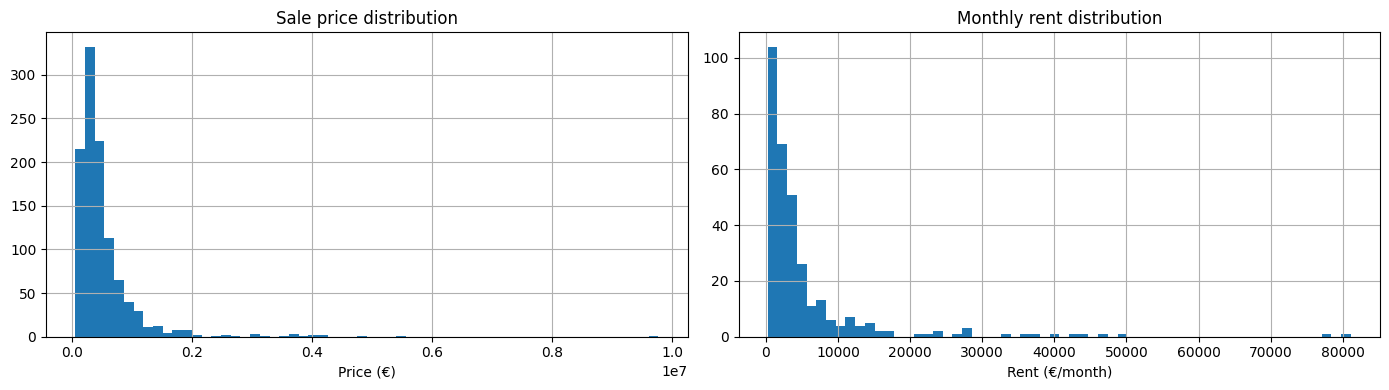


Sale price by commercial type:
                               count       mean        50%       min        max
SubtypeOfProperty                                                              
BUSINESS                       381.0   416152.0   300000.0   55000.0  4850000.0
COMMERCIAL_PREMISES            304.0   447836.0   355500.0   59900.0  3901101.0
GROUND_FLOOR                     1.0    60000.0    60000.0   60000.0    60000.0
HOTEL_RESTAURANT_CAFE           44.0   479850.0   365000.0   50000.0  1850000.0
INDUSTRIAL_PREMISES             49.0   807895.0   530685.0  120500.0  4186338.0
MIXED_USE_BUILDING               3.0   649333.0   700000.0  399000.0   849000.0
MIXED_USE_BUILDING_COMMERCIAL   90.0   600306.0   392500.0   65000.0  9767440.0
MIXED_USE_BUILDING_INDUSTRIES    2.0  2949500.0  2949500.0  399000.0  5500000.0
MIXED_USE_BUILDING_OFFICES      21.0   719752.0   599000.0  195000.0  2475000.0
OFFICES                         91.0   704998.0   424800.0   65000.0  3995000.0
OFFICE_B

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['TypeOfTransaction'] == 'for_sale']['Price'].hist(bins=60, ax=axes[0])
axes[0].set_title('Sale price distribution')
axes[0].set_xlabel('Price (€)')

df[df['TypeOfTransaction'] == 'for_rent']['Price'].hist(bins=60, ax=axes[1])
axes[1].set_title('Monthly rent distribution')
axes[1].set_xlabel('Rent (€/month)')

plt.tight_layout()
plt.show()

print('\nSale price by commercial type:')
print(
    df[df['TypeOfTransaction'] == 'for_sale']
    .groupby('SubtypeOfProperty')['Price']
    .describe()[['count', 'mean', '50%', 'min', 'max']]
    .round(0)
    .to_string()
)